# **Análisis Exploratorio Cuantitativo** 

# **Colombia Housing**

Este notebook es una guía base para el curso de Analítica de Datos, la cual incluye carga de datos y EDA.

**Nota**: En este contexto de Notebooks, no es necesario activar ambientes virtuales, ya que aquí no se automatizarán rutinas de código.


# Librerías

In [18]:
import warnings

warnings.filterwarnings("ignore")

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Carga de Datos

In [20]:
mainpath= "/Users/duvancatano/Documents/Data_Analytics_UdeA/ml-project/data/housing"
filename= "housing_dataset.csv"
fullpath= os.path.join(mainpath,filename)

In [21]:
data = pd.read_csv(fullpath, sep=",") # El separador es "," porque en el archivo .csv los valores están separados por coma
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame sin truncar

| Variable                                 | Significado                                                                                 |
| ---------------------------------------- | ------------------------------------------------------------------------------------------- |
| **departamento**                         | Departamento donde se encuentra ubicada la vivienda.                                        |
| **municipio**                            | Municipio específico dentro del departamento.                                               |
| **zona_urbana_rural**                    | Clasificación de la ubicación de la vivienda: zona urbana o zona rural.                     |
| **tipo_de_vivienda**                     | Tipo de vivienda (casa, apartamento, vivienda rural, entre otros).                          |
| **tenencia_de_la_vivienda**              | Forma de tenencia de la vivienda (propia, arrendada, familiar, etc.).                       |
| **area_total_m2**                        | Área total de la vivienda medida en metros cuadrados.                                       |
| **habitaciones**                         | Número de habitaciones o dormitorios de la vivienda.                                        |
| **banos**                                | Número de baños disponibles en la vivienda.                                                 |
| **pisos**                                | Número de pisos o niveles de la vivienda.                                                   |
| **antiguedad_de_la_vivienda**            | Edad de la vivienda en años desde su construcción.                                          |
| **calidad_de_construccion**              | Clasificación de la calidad de los materiales y del proceso de construcción de la vivienda. |
| **parqueaderos**                         | Número de espacios disponibles para estacionar vehículos.                                   |
| **estrato**                              | Estrato socioeconómico asignado a la vivienda.                                              |
| **tamano_del_hogar**                     | Número total de personas que viven en el hogar.                                             |
| **numero_de_ninos**                      | Número de niños que viven en el hogar.                                                      |
| **numero_de_adultos_mayores**            | Número de adultos mayores que viven en el hogar.                                            |
| **genero_del_jefe_del_hogar**            | Género del jefe o jefa del hogar.                                                           |
| **edad_del_jefe_del_hogar**              | Edad del jefe o jefa del hogar.                                                             |
| **nivel_educativo_del_jefe_del_hogar**   | Nivel educativo alcanzado por el jefe o jefa del hogar.                                     |
| **situacion_laboral_del_jefe_del_hogar** | Condición laboral del jefe o jefa del hogar (empleado, desempleado, independiente, etc.).   |
| **distancia_al_centro_de_la_ciudad_km**  | Distancia desde la vivienda hasta el centro de la ciudad medida en kilómetros.              |
| **indice_de_seguridad_del_barrio**       | Índice que mide el nivel de seguridad del barrio o vecindario.                              |
| **acceso_a_transporte_publico**          | Indica si la vivienda tiene acceso cercano a transporte público.                            |
| **acceso_a_internet**                    | Indica si el hogar cuenta con acceso a internet.                                            |
| **acceso_a_agua_potable**                | Indica si la vivienda tiene acceso a agua potable.                                          |
| **acceso_a_gas**                         | Indica si la vivienda cuenta con acceso a gas domiciliario.                                 |
| **indice_de_pobreza**                    | Índice que mide el nivel de pobreza del hogar o de la zona donde se ubica.                  |
| **acceso_a_credito**                     | Indica si el hogar tiene acceso a crédito financiero.                                       |
| **ahorros_del_hogar**                    | Cantidad o nivel de ahorros que posee el hogar.                                             |
| **ingreso_del_hogar**                    | Ingreso total percibido por el hogar.                                                       |
| **valor_de_mercado_de_la_vivienda**      | Valor estimado de mercado de la vivienda.                                                   |


### Defición del Problema

El conjunto de datos de Colombia Housing & Income Dataset contiene información sobre viviendas e ingresos en Colombia. El objetivo del análisis exploratorio cuantitativo de este conjunto de datos es identificar patrones, tendencias y relaciones entre las variables para comprender mejor las características de las viviendas y los ingresos en Colombia. Esto puede ayudar a responder preguntas como:

- ¿Cuáles son las características más comunes de las viviendas en Colombia?

- ¿Cómo varían los ingresos de los hogares según la ubicación geográfica?

- ¿Existe una relación entre el tamaño de la vivienda y el ingreso del hogar?

- ¿Cómo afecta el acceso a servicios públicos al valor de mercado de las viviendas?

- ¿Cuáles son los factores que influyen en el índice de pobreza en Colombia?

- ¿Cómo varía el acceso a crédito según el nivel educativo del jefe del hogar?

- ¿Cuál es la distribución de la antigüedad de las viviendas en Colombia?

- ¿Cómo afecta el estrato al precio de mercado de la vivienda?

- ¿Cómo afecta el ingreso del hogar al precio de mercado?

### **Objetivo Principal**

Construir un modelo de **Regresión** para predecir el **Valor de Mercado** de las viviendas en Colombia utilizando las características disponibles en el conjunto de datos. El análisis exploratorio cuantitativo se centrará en identificar las variables más relevantes para la predicción del valor de mercado y comprender las relaciones entre estas variables y el valor de mercado de las viviendas.

In [22]:
# Mostrar las primeras 10 filas del DataFrame #
data.head(10) 

,departamento,municipio,zona_urbana_rural,tipo_de_vivienda,tenencia_de_la_vivienda,area_total_m2,habitaciones,banos,pisos,antiguedad_de_la_vivienda,calidad_de_construccion,parqueaderos,estrato,tamano_del_hogar,numero_de_ninos,numero_de_adultos_mayores,genero_del_jefe_del_hogar,edad_del_jefe_del_hogar,nivel_educativo_del_jefe_del_hogar,situacion_laboral_del_jefe_del_hogar,distancia_al_centro_de_la_ciudad_km,indice_de_seguridad_del_barrio,acceso_a_transporte_publico,acceso_a_internet,acceso_a_agua_potable,acceso_a_gas,indice_de_pobreza,acceso_a_credito,ahorros_del_hogar,ingreso_del_hogar,valor_de_mercado_de_la_vivienda
0,Risaralda,Cali,Urban,Apartment,Rented,278.818512,3,2,1,8,Medium,0,5,1,2,0,Female,58,Primary,Informal,4.650399,75.040401,Yes,Yes,Yes,No,0.126217,Yes,2.594791e+06,3.380097e+06,276.377525
1,Atlántico,Manizales,Urban,Apartment,Owned,84.332953,2,1,1,50,Low,2,2,1,1,0,Male,51,Primary,Informal,25.125257,65.597371,Yes,Yes,Yes,Yes,0.137717,Yes,3.700521e+06,1.156504e+06,60.736798
2,Santander,Pereira,Urban,House,Rented,102.913662,5,2,2,59,Low,2,1,5,0,0,Male,48,Primary,Informal,21.855367,83.193839,Yes,Yes,Yes,Yes,0.376104,No,4.695727e+06,7.676671e+05,91.551183
3,Risaralda,Manizales,Urban,House,Owned,89.829627,5,1,2,44,High,1,1,6,1,0,Male,40,Postgraduate,Formal,5.968512,53.145852,Yes,Yes,Yes,Yes,0.462843,Yes,2.345105e+06,4.792603e+06,71.359184
4,Valle del Cauca,Manizales,Urban,Farm,Rented,42.678735,2,3,1,59,Low,2,1,2,3,1,Female,38,University,Formal,10.599648,41.474856,Yes,Yes,Yes,Yes,0.258479,No,6.741529e+05,3.682280e+06,68.303887
5,Caldas,Cali,Rural,Farm,Rented,152.827117,3,1,3,57,Medium,2,2,6,0,2,Male,53,University,Informal,19.610462,74.499453,Yes,Yes,Yes,Yes,0.361124,Yes,1.626570e+06,4.889885e+06,84.715637
6,Santander,Cartagena,Urban,Apartment,Rented,229.480693,2,1,3,53,Low,1,3,3,0,0,Male,54,Primary,Formal,26.489972,64.937339,No,Yes,Yes,Yes,0.444136,Yes,1.824982e+06,4.953239e+06,183.910568
7,Santander,Barranquilla,Urban,House,Family,106.141538,1,3,1,48,Low,0,3,3,3,0,Female,37,Primary,Formal,2.564339,94.131428,No,Yes,Yes,Yes,0.206167,No,1.115595e+06,4.954487e+06,157.436239
8,Risaralda,Cali,Urban,Farm,Family,108.481944,5,3,2,12,High,0,3,3,2,2,Female,65,Postgraduate,Informal,13.765686,96.596665,No,Yes,Yes,No,0.148384,No,1.073865e+06,7.504212e+06,143.068202
9,Cundinamarca,Bucaramanga,Urban,Farm,Family,159.862473,4,2,1,20,Low,0,1,4,1,0,Female,31,Secondary,Informal,11.130486,61.333667,Yes,Yes,Yes,No,0.151278,Yes,7.376213e+05,4.598806e+05,130.398556


In [23]:
# Mostrar las últimas 10 filas del DataFrame #
data.tail(10)

,departamento,municipio,zona_urbana_rural,tipo_de_vivienda,tenencia_de_la_vivienda,area_total_m2,habitaciones,banos,pisos,antiguedad_de_la_vivienda,calidad_de_construccion,parqueaderos,estrato,tamano_del_hogar,numero_de_ninos,numero_de_adultos_mayores,genero_del_jefe_del_hogar,edad_del_jefe_del_hogar,nivel_educativo_del_jefe_del_hogar,situacion_laboral_del_jefe_del_hogar,distancia_al_centro_de_la_ciudad_km,indice_de_seguridad_del_barrio,acceso_a_transporte_publico,acceso_a_internet,acceso_a_agua_potable,acceso_a_gas,indice_de_pobreza,acceso_a_credito,ahorros_del_hogar,ingreso_del_hogar,valor_de_mercado_de_la_vivienda
9990,Caldas,Medellín,Urban,Farm,Family,18.640335,3,1,1,45,Medium,1,5,5,1,2,Female,46,University,Formal,19.826621,73.125891,Yes,Yes,Yes,Yes,0.315944,Yes,2.100330e+06,1.490984e+07,87.579165
9991,Atlántico,Cartagena,Urban,Farm,Family,103.122721,3,1,1,56,Low,2,3,1,2,2,Female,72,Primary,Informal,41.227040,86.652118,Yes,No,Yes,No,0.367744,Yes,1.810605e+06,3.061416e+06,120.267247
9992,Bolívar,Manizales,Urban,House,Rented,23.465481,5,1,3,37,High,0,2,4,3,2,Female,71,Postgraduate,Informal,5.342682,33.096482,No,Yes,Yes,Yes,0.113233,Yes,3.107318e+05,5.418204e+06,13.538141
9993,Cundinamarca,Medellín,Urban,Apartment,Family,46.279045,1,1,2,15,Medium,2,5,3,1,1,Female,33,University,Informal,28.503916,83.375593,Yes,Yes,Yes,Yes,0.391769,No,1.061692e+06,1.033796e+07,97.673192
9994,Atlántico,Bogotá,Rural,House,Family,220.069401,4,1,1,38,Low,1,4,7,1,1,Male,67,University,Formal,18.357368,48.506729,Yes,Yes,Yes,Yes,0.389944,Yes,1.546393e+06,1.258141e+07,174.218273
9995,Atlántico,Medellín,Rural,Farm,Owned,44.785777,5,2,2,26,Medium,1,4,7,3,0,Male,42,University,Formal,7.564589,44.679049,Yes,Yes,Yes,Yes,0.093752,Yes,3.638528e+05,9.962925e+06,98.699080
9996,Valle del Cauca,Bucaramanga,Urban,Farm,Owned,212.692186,2,2,2,5,Medium,1,3,6,3,0,Male,53,University,Formal,4.444607,84.176653,Yes,Yes,Yes,Yes,0.128719,Yes,5.923286e+06,6.589388e+06,161.871038
9997,Bolívar,Bucaramanga,Urban,Apartment,Rented,88.367240,1,2,3,28,High,1,5,1,3,1,Male,76,Secondary,Formal,14.239031,63.351928,Yes,Yes,Yes,Yes,0.180326,Yes,1.838470e+06,9.183064e+06,141.413649
9998,Bolívar,Manizales,Urban,House,Family,174.632270,2,2,3,39,High,0,2,5,2,0,Female,36,Secondary,Formal,2.272512,92.391629,Yes,Yes,Yes,Yes,0.252038,No,2.983078e+06,3.835472e+06,147.394305
9999,Santander,Pereira,Urban,House,Rented,79.573517,1,3,1,16,Low,2,2,7,0,1,Male,71,University,Unemployed,5.779677,43.407024,Yes,Yes,Yes,Yes,0.284505,No,2.596318e+05,1.644042e+06,72.067965


In [26]:
data.columns.to_list()

['departamento',
 'municipio',
 'zona_urbana_rural',
 'tipo_de_vivienda',
 'tenencia_de_la_vivienda',
 'area_total_m2',
 'habitaciones',
 'banos',
 'pisos',
 'antiguedad_de_la_vivienda',
 'calidad_de_construccion',
 'parqueaderos',
 'estrato',
 'tamano_del_hogar',
 'numero_de_ninos',
 'numero_de_adultos_mayores',
 'genero_del_jefe_del_hogar',
 'edad_del_jefe_del_hogar',
 'nivel_educativo_del_jefe_del_hogar',
 'situacion_laboral_del_jefe_del_hogar',
 'distancia_al_centro_de_la_ciudad_km',
 'indice_de_seguridad_del_barrio',
 'acceso_a_transporte_publico',
 'acceso_a_internet',
 'acceso_a_agua_potable',
 'acceso_a_gas',
 'indice_de_pobreza',
 'acceso_a_credito',
 'ahorros_del_hogar',
 'ingreso_del_hogar',
 'valor_de_mercado_de_la_vivienda']

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   departamento                          10000 non-null  object 
 1   municipio                             10000 non-null  object 
 2   zona_urbana_rural                     10000 non-null  object 
 3   tipo_de_vivienda                      10000 non-null  object 
 4   tenencia_de_la_vivienda               10000 non-null  object 
 5   area_total_m2                         10000 non-null  float64
 6   habitaciones                          10000 non-null  int64  
 7   banos                                 10000 non-null  int64  
 8   pisos                                 10000 non-null  int64  
 9   antiguedad_de_la_vivienda             10000 non-null  int64  
 10  calidad_de_construccion               10000 non-null  object 
 11  parqueaderos    

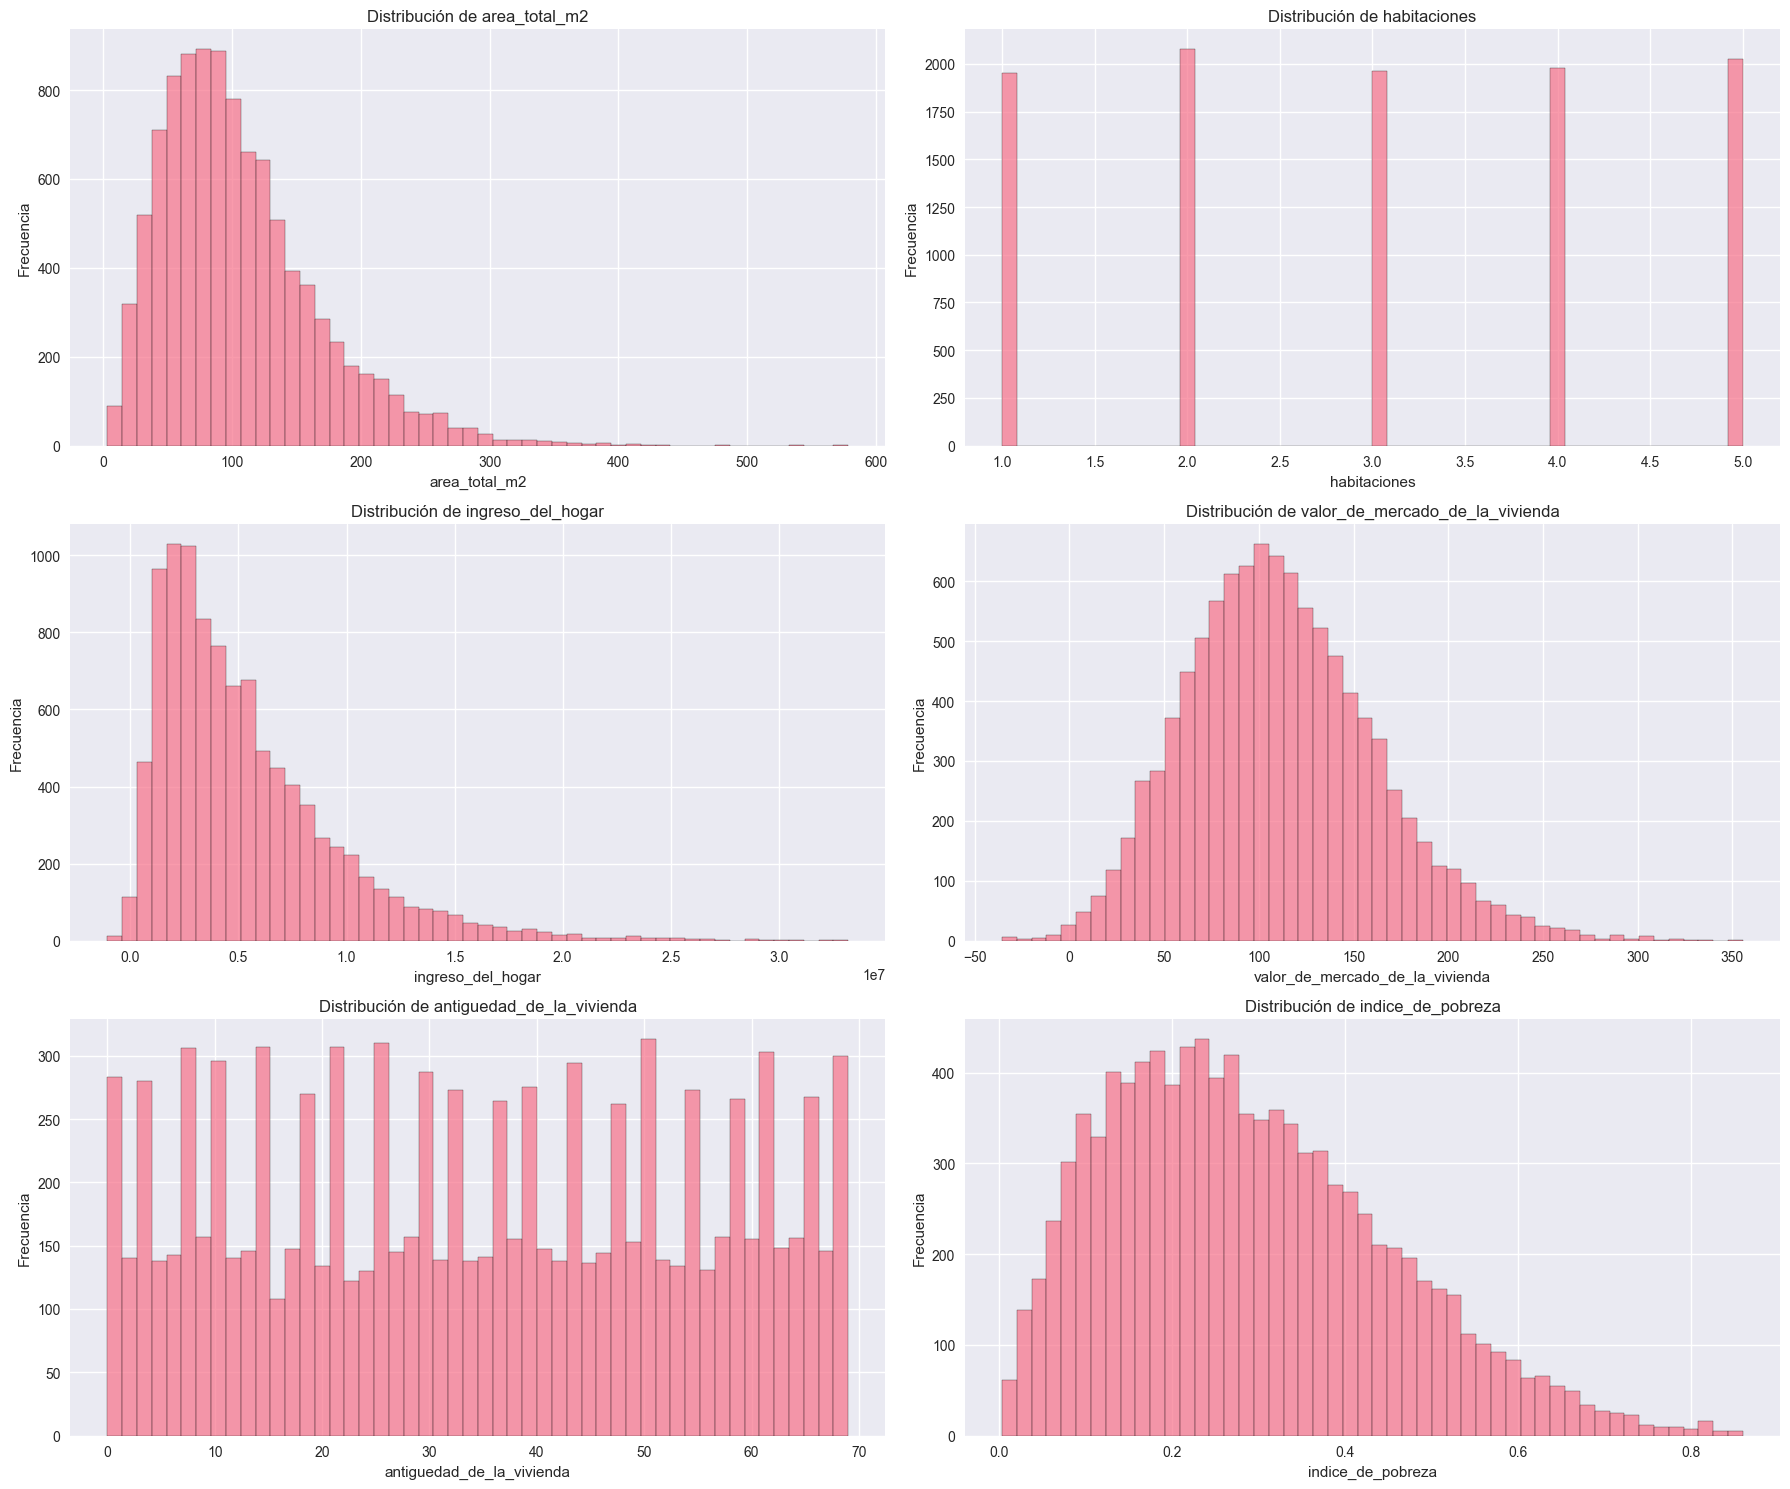

In [37]:
# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
figsize = (12, 8)

## EDA VISUAL: Distribuciones univariadas
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.ravel()

# Variables clave numéricas
vars_num = ['area_total_m2', 'habitaciones', 'ingreso_del_hogar', 'valor_de_mercado_de_la_vivienda', 
            'antiguedad_de_la_vivienda', 'indice_de_pobreza']
for i, var in enumerate(vars_num):
    axes[i].hist(data[var], bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('eda_distribuciones.png', dpi=300, bbox_inches='tight')
plt.show()

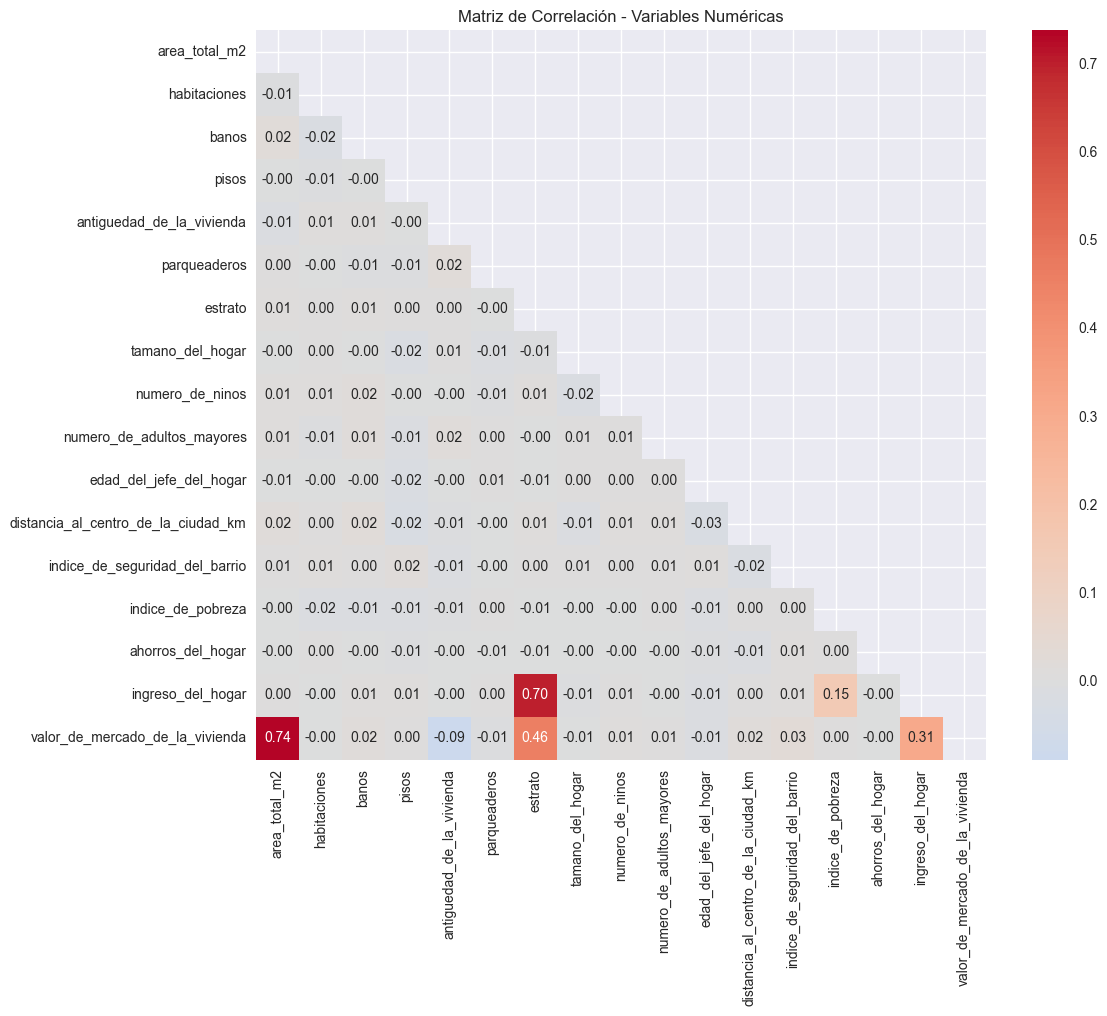

In [38]:
## EDA VISUAL: Correlación entre variables numéricas
plt.figure(figsize=(12, 10))
corr = data.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

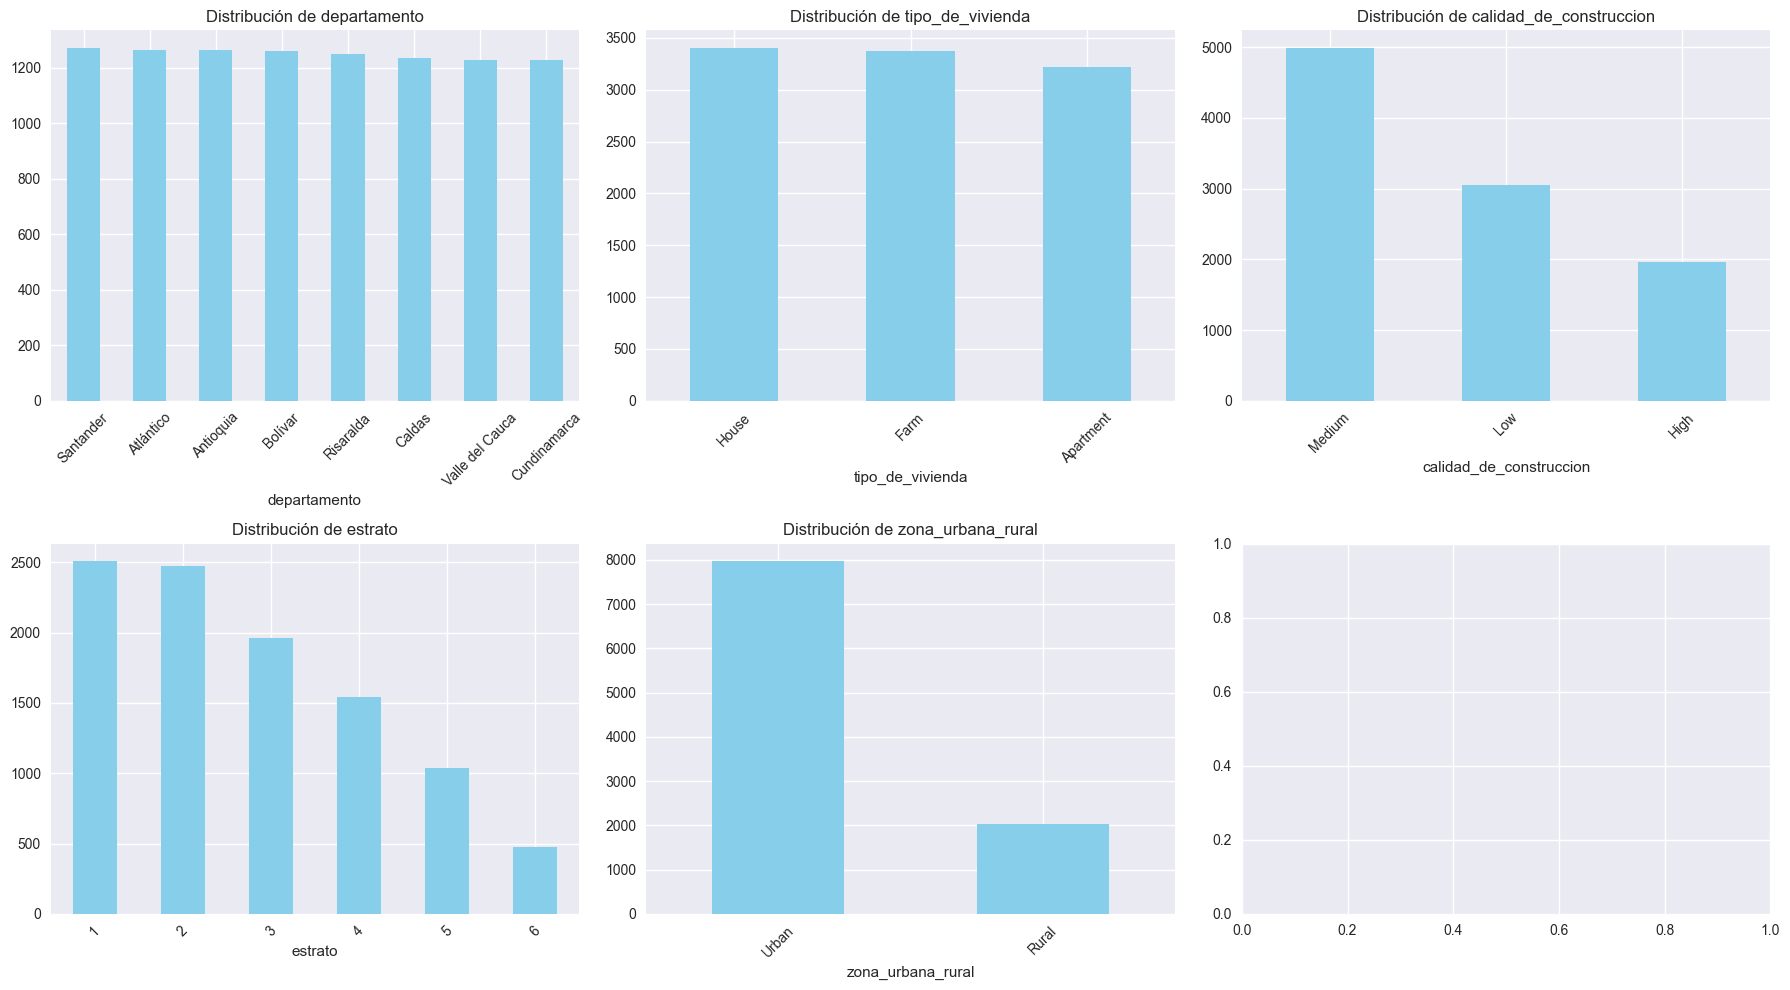

In [39]:
## EDA VISUAL: Conteos categóricos clave
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

cat_vars = ['departamento', 'tipo_de_vivienda', 'calidad_de_construccion', 'estrato', 'zona_urbana_rural']
for i, var in enumerate(cat_vars):
    if i < 5:
        df[var].value_counts().plot(kind='bar', ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribución de {var}')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_categoricas.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# 1. Características más comunes de las viviendas
print("\n1. CARACTERÍSTICAS MÁS COMUNES:")
comunes = {
    'Tipo vivienda': data['tipo_de_vivienda'].mode()[0],
    'Tenencia': data['tenencia_de_la_vivienda'].mode()[0],
    'Zona': data['zona_urbana_rural'].mode()[0],
    'Calidad': data['calidad_de_construccion'].mode()[0],
    'Estrato': data['estrato'].mode()[0],
    'Habitaciones promedio': data['habitaciones'].mean(),
    'Baños promedio': data['banos'].mean(),
    'Área promedio m²': data['area_total_m2'].mean()
}
print(pd.Series(comunes))


1. CARACTERÍSTICAS MÁS COMUNES:
Tipo vivienda                 House
Tenencia                     Rented
Zona                          Urban
Calidad                      Medium
Estrato                           1
Habitaciones promedio        3.0044
Baños promedio               1.9973
Área promedio m²         105.365402
dtype: object



2. INGRESOS POR UBICACIÓN:
                      mean     median  count
departamento                                
Antioquia        5527932.0  4398252.0   1265
Atlántico        5251607.0  4248388.0   1265
Bolívar          5047860.0  4200821.0   1259
Caldas           5452630.0  4242746.0   1236
Cundinamarca     5299897.0  4107708.0   1227
Risaralda        5224213.0  4159313.0   1249
Santander        5230777.0  4067701.0   1271
Valle del Cauca  5424659.0  4370779.0   1228


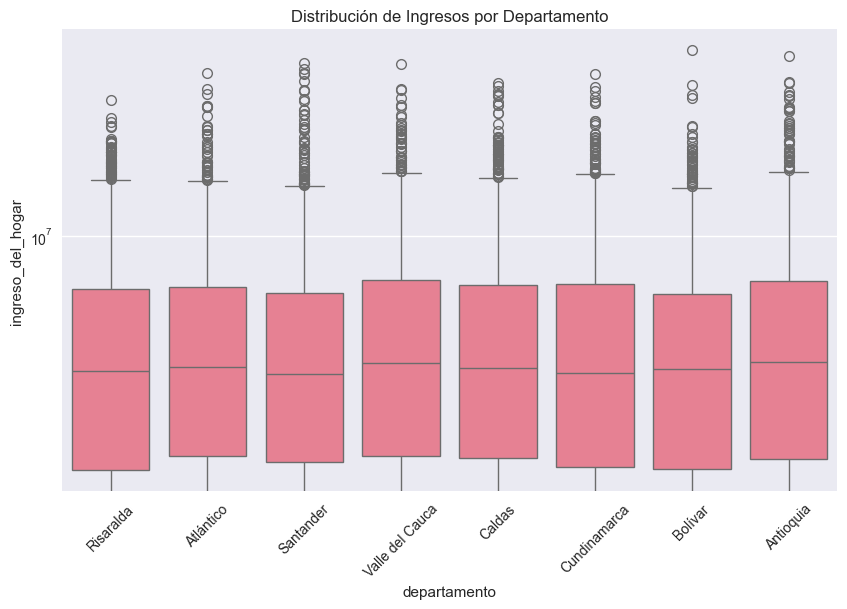

In [43]:
## 2. Ingresos según ubicación geográfica
print("\n2. INGRESOS POR UBICACIÓN:")
ingresos_loc = data.groupby('departamento')['ingreso_del_hogar'].agg(['mean', 'median', 'count']).round(0)
print(ingresos_loc)

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='departamento', y='ingreso_del_hogar')
plt.title('Distribución de Ingresos por Departamento')
plt.xticks(rotation=45)
plt.yscale('log')
plt.savefig('p2_ingresos_ubicacion.png', dpi=300, bbox_inches='tight')
plt.show()


3. RELACIÓN TAMAÑO vs INGRESO:
Correlación Pearson: 0.003


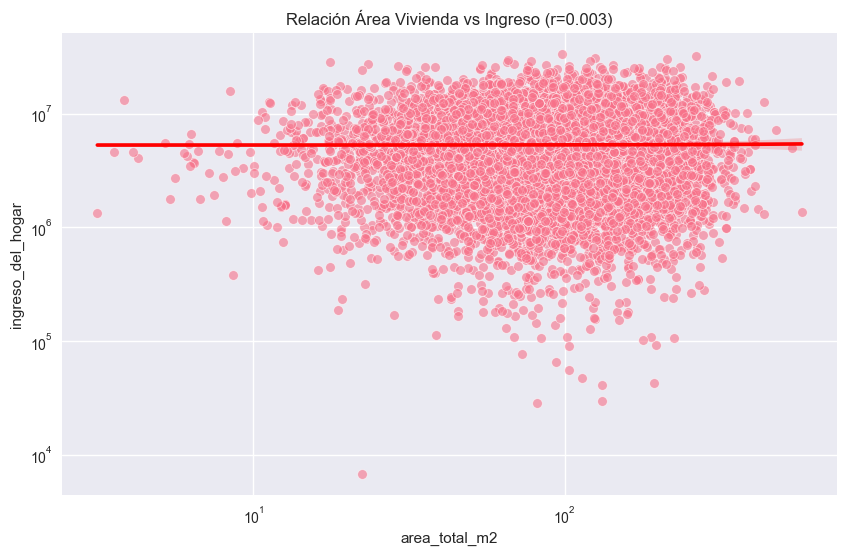

In [44]:
## 3. Relación tamaño vivienda vs ingreso hogar
print("\n3. RELACIÓN TAMAÑO vs INGRESO:")
corr_tamaño_ingreso = data['area_total_m2'].corr(data['ingreso_del_hogar'])
print(f'Correlación Pearson: {corr_tamaño_ingreso:.3f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='area_total_m2', y='ingreso_del_hogar', alpha=0.6)
sns.regplot(data=data, x='area_total_m2', y='ingreso_del_hogar', scatter=False, color='red')
plt.title(f'Relación Área Vivienda vs Ingreso (r={corr_tamaño_ingreso:.3f})')
plt.xscale('log')
plt.yscale('log')
plt.savefig('p3_tamaño_ingreso.png', dpi=300, bbox_inches='tight')
plt.show()


4. SERVICIOS PÚBLICOS vs VALOR MERCADO:
acceso_a_transporte_publico: Sí=$nan, No=$110, Diferencia=nan%
acceso_a_internet: Sí=$nan, No=$110, Diferencia=nan%
acceso_a_agua_potable: Sí=$nan, No=$114, Diferencia=nan%
acceso_a_gas: Sí=$nan, No=$110, Diferencia=nan%


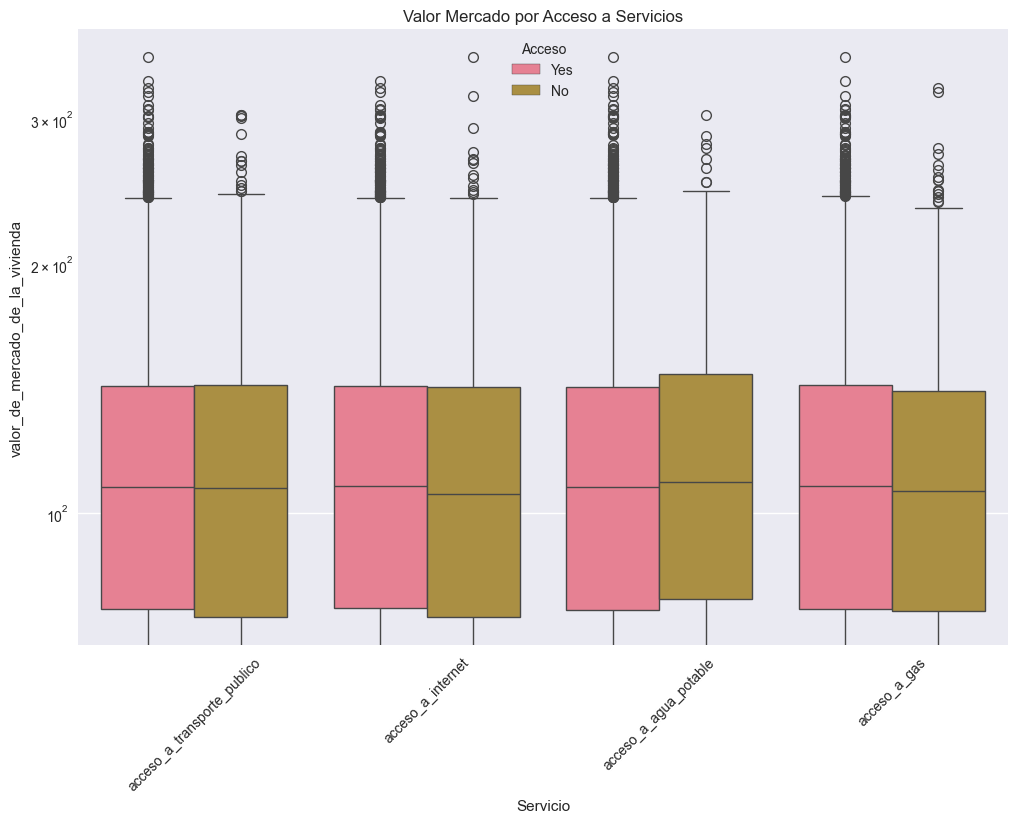

In [45]:
## 4. Acceso servicios públicos vs valor mercado
print("\n4. SERVICIOS PÚBLICOS vs VALOR MERCADO:")
servicios = ['acceso_a_transporte_publico', 'acceso_a_internet', 'acceso_a_agua_potable', 'acceso_a_gas']
for serv in servicios:
    valor_si = data[data[serv]=='Sí']['valor_de_mercado_de_la_vivienda'].mean()
    valor_no = data[data[serv]=='No']['valor_de_mercado_de_la_vivienda'].mean()
    print(f"{serv}: Sí=${valor_si:,.0f}, No=${valor_no:,.0f}, Diferencia={((valor_si/valor_no)-1)*100:.1f}%")

# Gráfico servicios vs valor
df_serv = data[servicios + ['valor_de_mercado_de_la_vivienda']].melt(id_vars='valor_de_mercado_de_la_vivienda', 
                                                                    var_name='Servicio', value_name='Acceso')
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_serv, x='Servicio', y='valor_de_mercado_de_la_vivienda', hue='Acceso')
plt.title('Valor Mercado por Acceso a Servicios')
plt.xticks(rotation=45)
plt.yscale('log')
plt.savefig('p4_servicios_valor.png', dpi=300, bbox_inches='tight')
plt.show()


5. FACTORES ÍNDICE POBREZA:
Correlación estrato vs pobreza: -0.006
Correlación ingreso_del_hogar vs pobreza: 0.154

nivel_educativo_del_jefe_del_hogar:
nivel_educativo_del_jefe_del_hogar
University      0.285767
Primary         0.286424
Postgraduate    0.286790
Secondary       0.289980
Name: indice_de_pobreza, dtype: float64


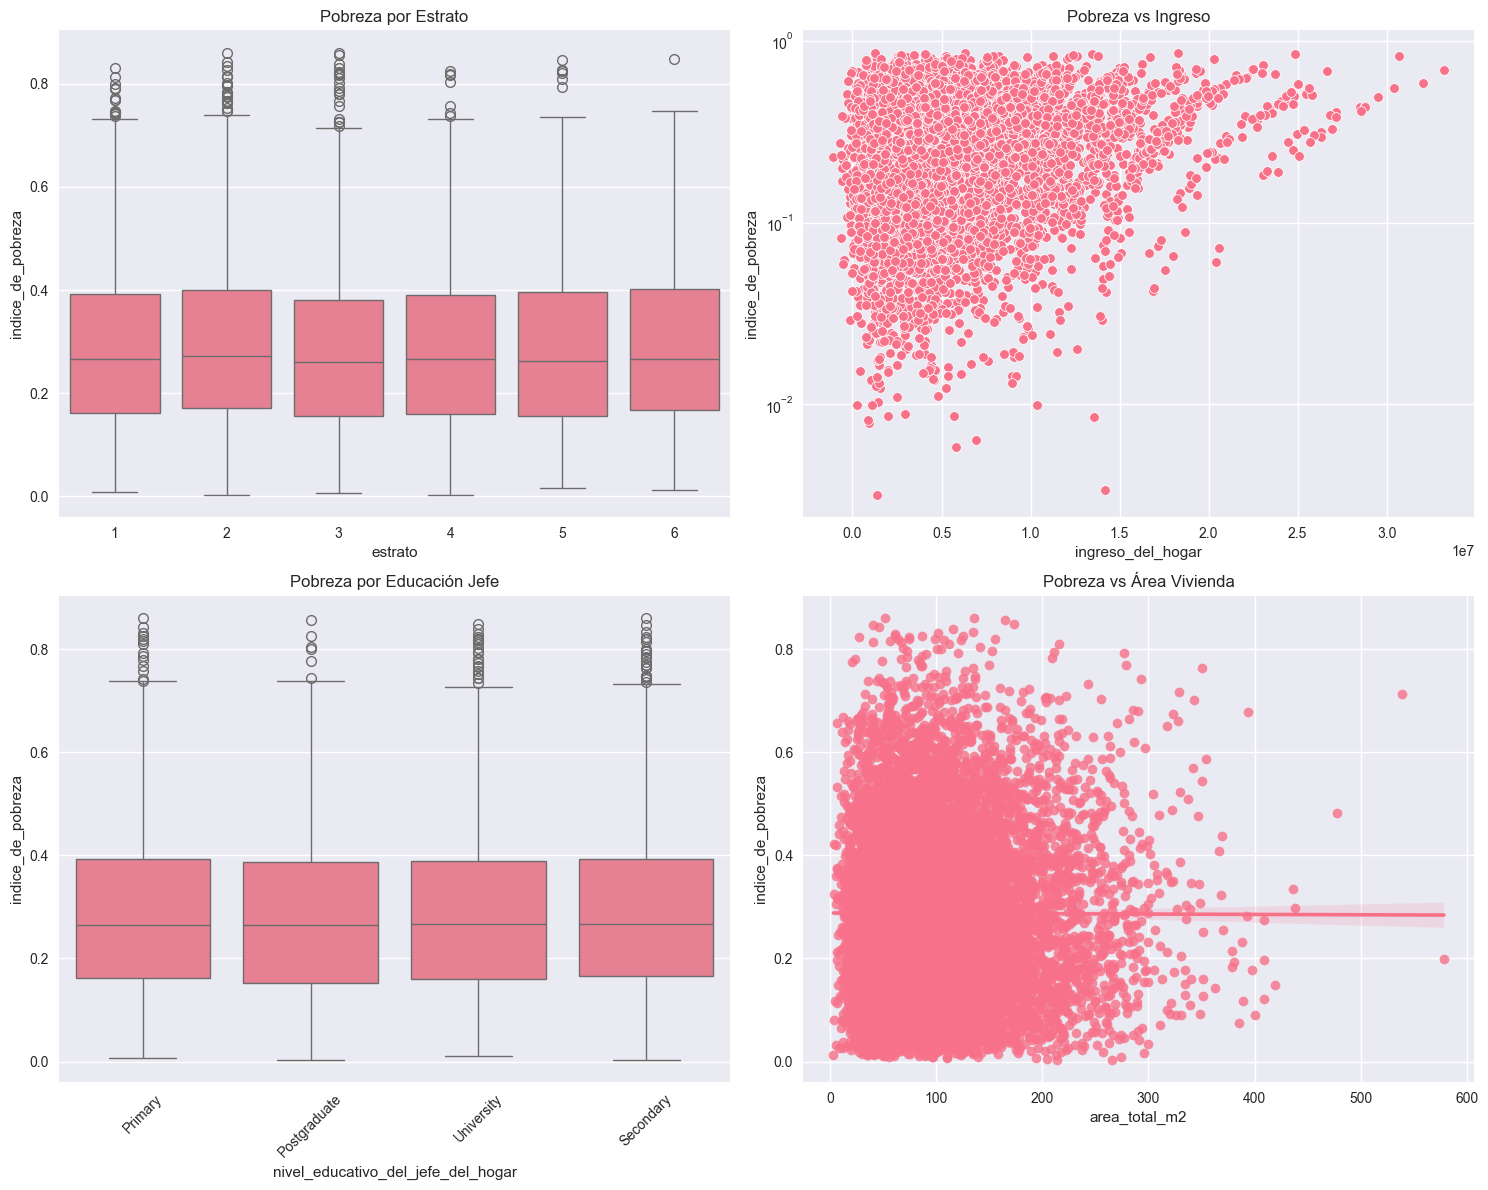

In [46]:
## 5. Factores que influyen en índice de pobreza
print("\n5. FACTORES ÍNDICE POBREZA:")
vars_pobreza = ['estrato', 'ingreso_del_hogar', 'nivel_educativo_del_jefe_del_hogar', 'area_total_m2']
for var in vars_pobreza[:-1]:
    if data[var].dtype == 'object':
        pob_edu = data.groupby(var)['indice_de_pobreza'].mean().sort_values()
        print(f"\n{var}:\n{pob_edu}")
    else:
        corr = df[var].corr(df['indice_de_pobreza'])
        print(f"Correlación {var} vs pobreza: {corr:.3f}")

# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
sns.boxplot(data=data, x='estrato', y='indice_de_pobreza', ax=axes[0,0])
axes[0,0].set_title('Pobreza por Estrato')

sns.scatterplot(data=data, x='ingreso_del_hogar', y='indice_de_pobreza', ax=axes[0,1])
axes[0,1].set_yscale('log')
axes[0,1].set_title('Pobreza vs Ingreso')

sns.boxplot(data=data, x='nivel_educativo_del_jefe_del_hogar', y='indice_de_pobreza', ax=axes[1,0])
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_title('Pobreza por Educación Jefe')

sns.regplot(data=data, x='area_total_m2', y='indice_de_pobreza', ax=axes[1,1])
axes[1,1].set_title('Pobreza vs Área Vivienda')

plt.tight_layout()
plt.savefig('p5_factores_pobreza.png', dpi=300, bbox_inches='tight')
plt.show()


7. DISTRIBUCIÓN ANTIGÜEDAD:
Media: 34.5328
Mediana: 34.0
Por estrato:
              mean  median
estrato                   
1        34.308612    34.0
2        34.328213    34.0
3        35.147224    36.0
4        35.040883    35.0
5        33.902697    33.0
6        33.972689    34.0


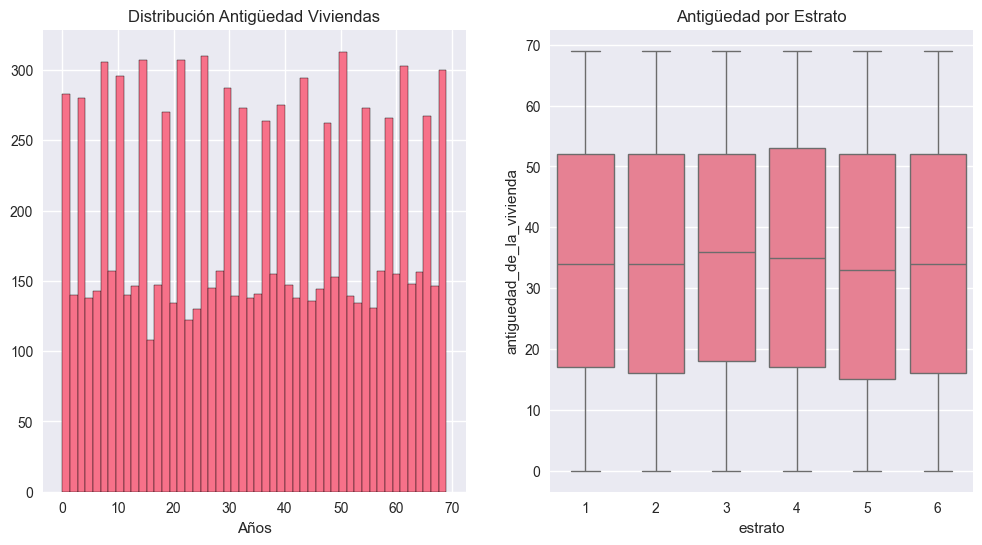

In [50]:
## 7. Distribución antigüedad viviendas
print("\n7. DISTRIBUCIÓN ANTIGÜEDAD:")
print("Media:", data['antiguedad_de_la_vivienda'].mean())
print("Mediana:", data['antiguedad_de_la_vivienda'].median())
print("Por estrato:")
print(data.groupby('estrato')['antiguedad_de_la_vivienda'].agg(['mean', 'median']))

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
df['antiguedad_de_la_vivienda'].hist(bins=50, edgecolor='black')
plt.title('Distribución Antigüedad Viviendas')
plt.xlabel('Años')

plt.subplot(1,2,2)
sns.boxplot(data=data, x='estrato', y='antiguedad_de_la_vivienda')
plt.title('Antigüedad por Estrato')
plt.savefig('p7_antiguedad.png', dpi=300, bbox_inches='tight')
plt.show()

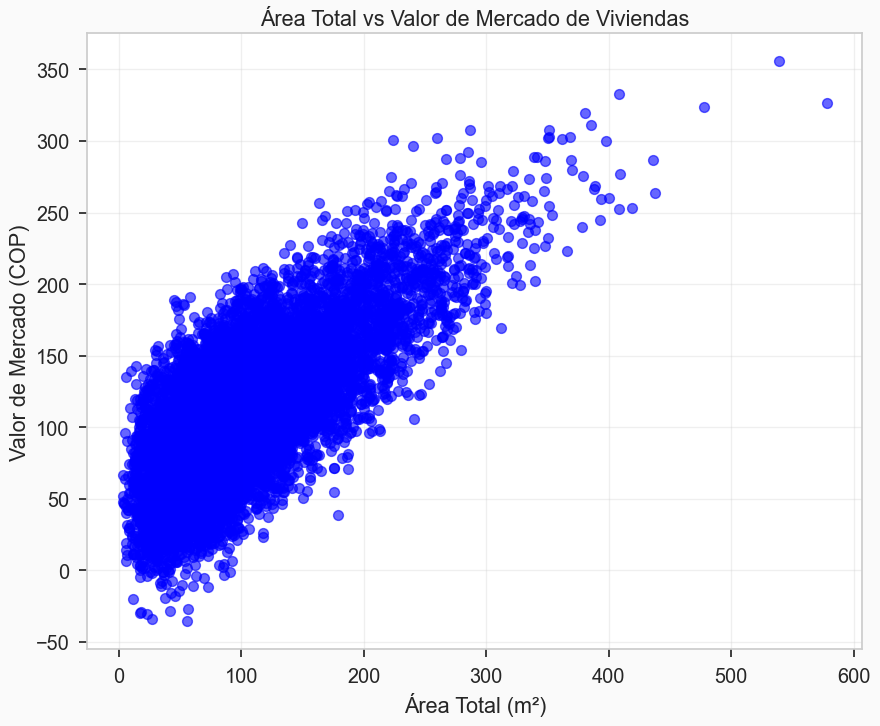

In [56]:
# Crear diagrama de dispersión sencillo
plt.figure(figsize=(10, 8))

plt.scatter(data['area_total_m2'], data['valor_de_mercado_de_la_vivienda'], 
           alpha=0.6, color='blue', s=50)

# Agregar títulos y etiquetas
plt.xlabel('Área Total (m²)')
plt.ylabel('Valor de Mercado (COP)')
plt.title('Área Total vs Valor de Mercado de Viviendas')

# Agregar grid
plt.grid(True, alpha=0.3)

# Mostrar gráfico
plt.show()

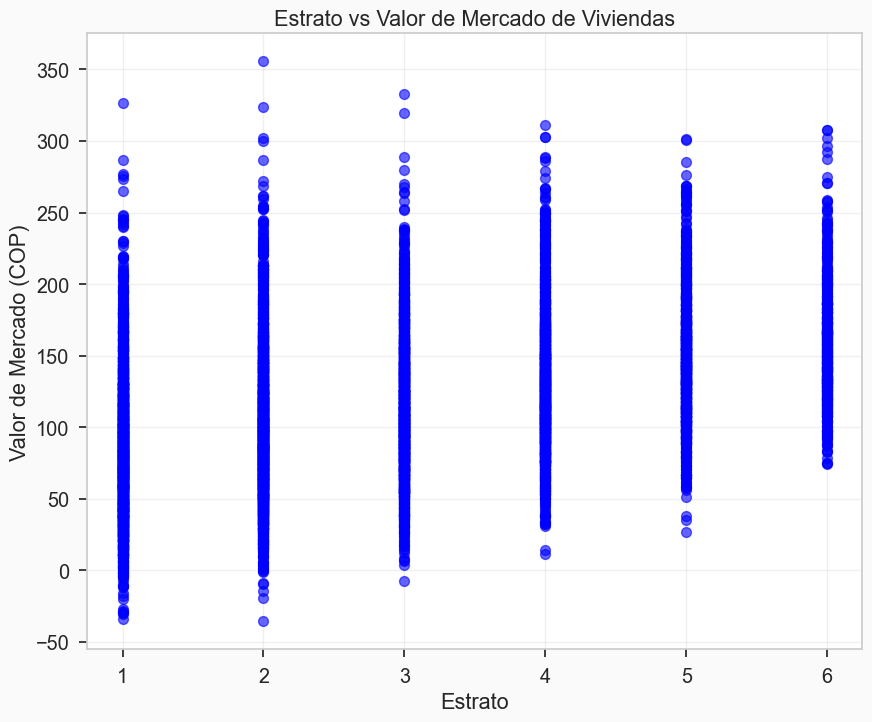

In [58]:
# Crear diagrama de dispersión sencillo
plt.figure(figsize=(10, 8))

plt.scatter(data['estrato'], data['valor_de_mercado_de_la_vivienda'], 
           alpha=0.6, color='blue', s=50)

# Agregar títulos y etiquetas
plt.xlabel('Estrato')
plt.ylabel('Valor de Mercado (COP)')
plt.title('Estrato vs Valor de Mercado de Viviendas')

# Agregar grid
plt.grid(True, alpha=0.3)

# Mostrar gráfico
plt.show()

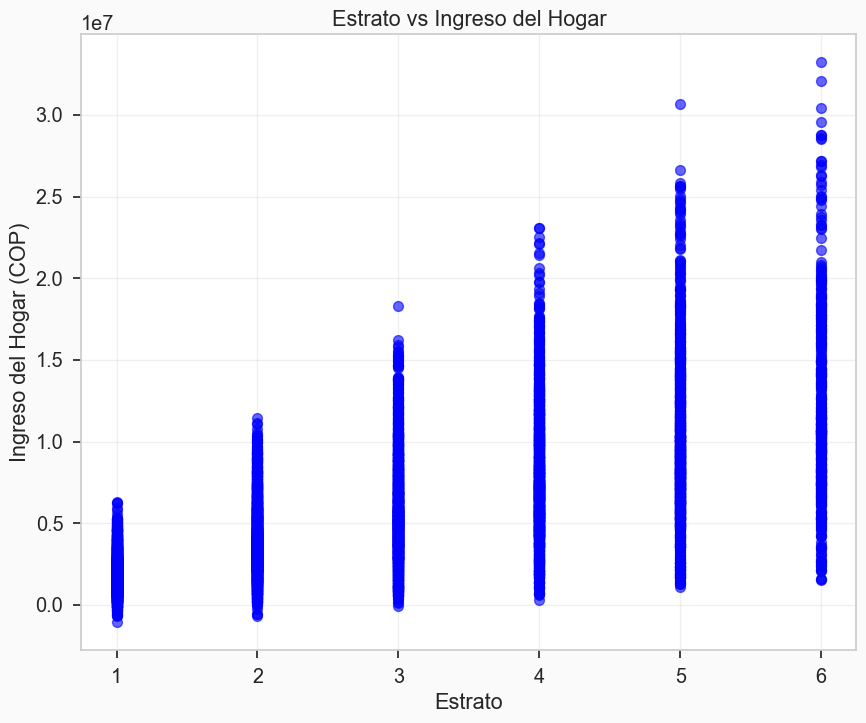

In [60]:
# Crear diagrama de dispersión sencillo
plt.figure(figsize=(10, 8))

plt.scatter(data['estrato'], data['ingreso_del_hogar'], 
           alpha=0.6, color='blue', s=50)

# Agregar títulos y etiquetas
plt.xlabel('Estrato')
plt.ylabel('Ingreso del Hogar (COP)')
plt.title('Estrato vs Ingreso del Hogar')

# Agregar grid
plt.grid(True, alpha=0.3)

# Mostrar gráfico
plt.show()

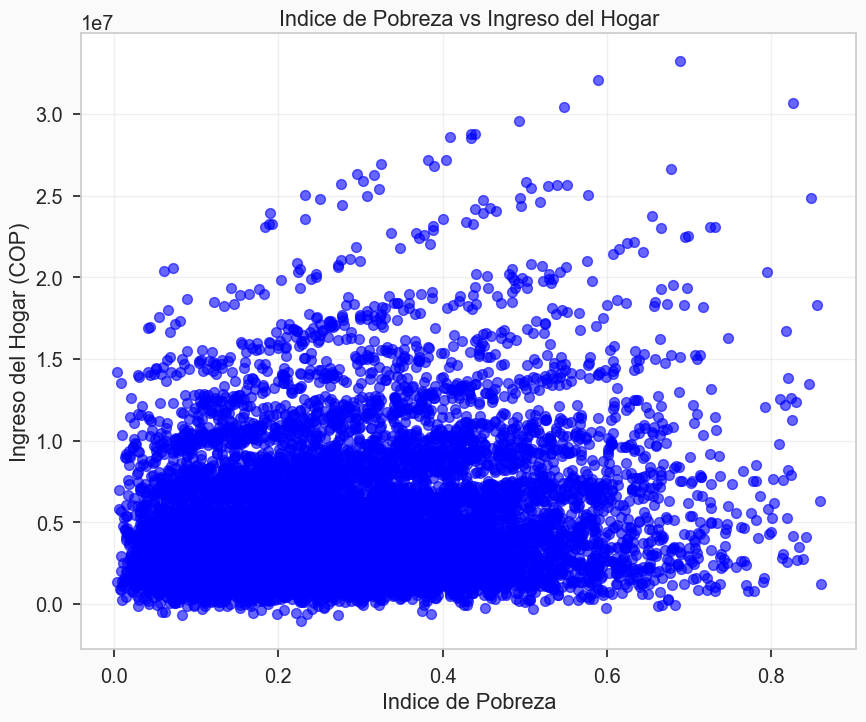

In [61]:
# Crear diagrama de dispersión sencillo
plt.figure(figsize=(10, 8))

plt.scatter(data['indice_de_pobreza'], data['ingreso_del_hogar'], 
           alpha=0.6, color='blue', s=50)

# Agregar títulos y etiquetas
plt.xlabel('Indice de Pobreza')
plt.ylabel('Ingreso del Hogar (COP)')
plt.title('Indice de Pobreza vs Ingreso del Hogar')

# Agregar grid
plt.grid(True, alpha=0.3)

# Mostrar gráfico
plt.show()

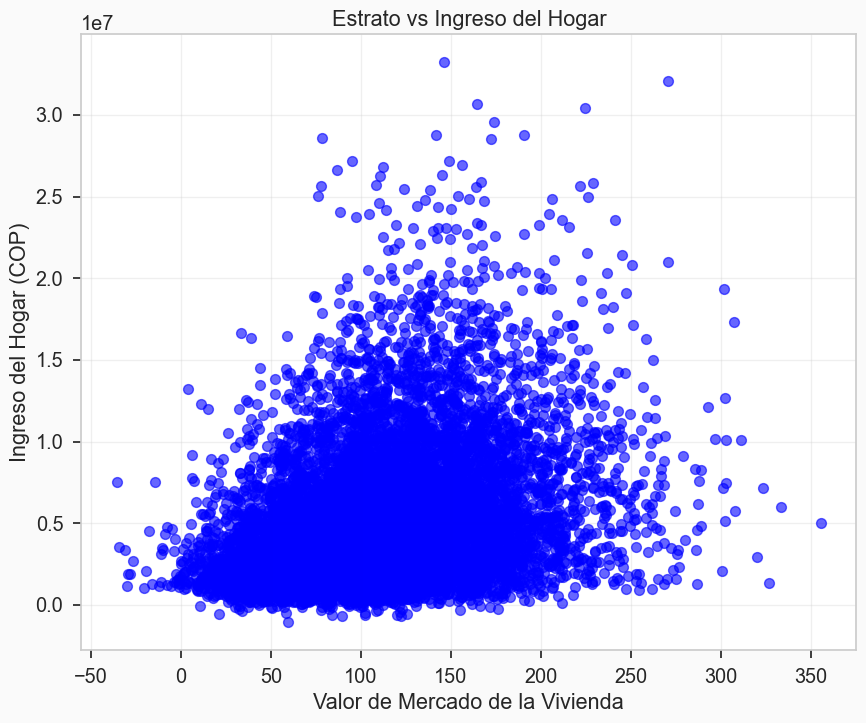

In [62]:
# Crear diagrama de dispersión sencillo
plt.figure(figsize=(10, 8))

plt.scatter(data['valor_de_mercado_de_la_vivienda'], data['ingreso_del_hogar'], 
           alpha=0.6, color='blue', s=50)

# Agregar títulos y etiquetas
plt.xlabel('Valor de Mercado de la Vivienda')
plt.ylabel('Ingreso del Hogar (COP)')
plt.title('Estrato vs Ingreso del Hogar')

# Agregar grid
plt.grid(True, alpha=0.3)

# Mostrar gráfico
plt.show()

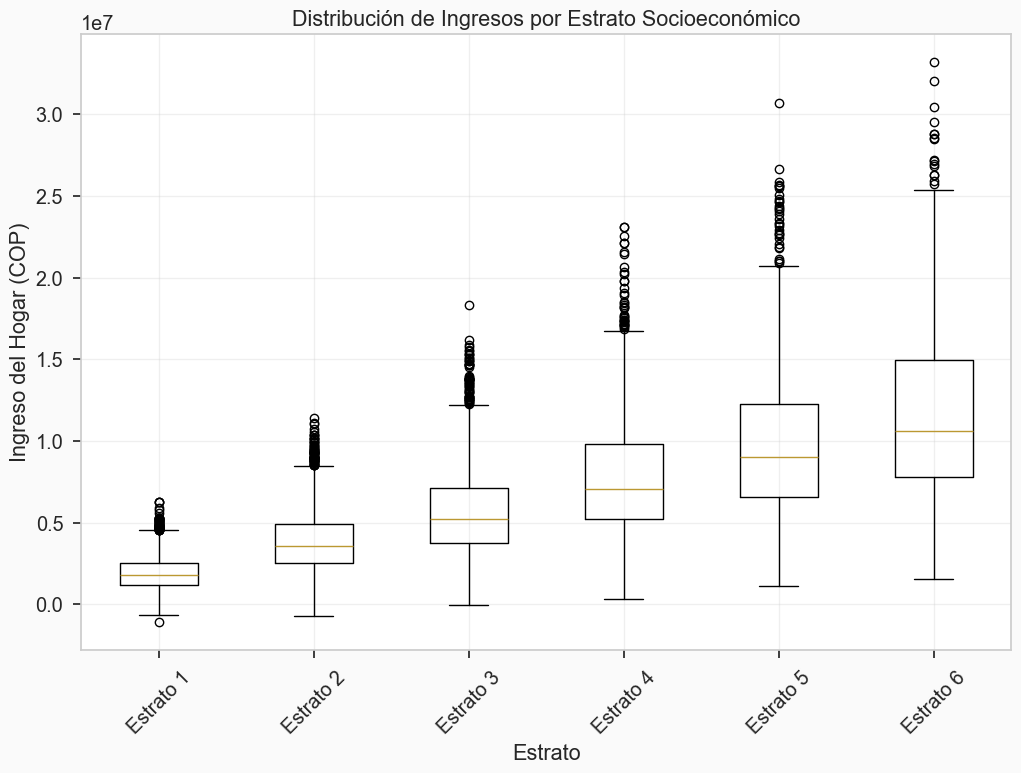

In [63]:
# Crear boxplot por estrato
plt.figure(figsize=(12, 8))

plt.boxplot([data[data['estrato']==i]['ingreso_del_hogar'] for i in range(1,7)],
            labels=['Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6'])

# Agregar títulos y etiquetas
plt.xlabel('Estrato')
plt.ylabel('Ingreso del Hogar (COP)')
plt.title('Distribución de Ingresos por Estrato Socioeconómico')

# Agregar grid
plt.grid(True, alpha=0.3)

# Rotar etiquetas si es necesario
plt.xticks(rotation=45)

# Mostrar gráfico
plt.show()

In [59]:
data.columns.tolist()

['departamento',
 'municipio',
 'zona_urbana_rural',
 'tipo_de_vivienda',
 'tenencia_de_la_vivienda',
 'area_total_m2',
 'habitaciones',
 'banos',
 'pisos',
 'antiguedad_de_la_vivienda',
 'calidad_de_construccion',
 'parqueaderos',
 'estrato',
 'tamano_del_hogar',
 'numero_de_ninos',
 'numero_de_adultos_mayores',
 'genero_del_jefe_del_hogar',
 'edad_del_jefe_del_hogar',
 'nivel_educativo_del_jefe_del_hogar',
 'situacion_laboral_del_jefe_del_hogar',
 'distancia_al_centro_de_la_ciudad_km',
 'indice_de_seguridad_del_barrio',
 'acceso_a_transporte_publico',
 'acceso_a_internet',
 'acceso_a_agua_potable',
 'acceso_a_gas',
 'indice_de_pobreza',
 'acceso_a_credito',
 'ahorros_del_hogar',
 'ingreso_del_hogar',
 'valor_de_mercado_de_la_vivienda']